<a href="https://colab.research.google.com/github/prince23696/NLU-Assignment/blob/main/G25AIT1122_NLU_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Setup & Dependencies

In [26]:
!pip install -q nltk bert-score sacremoses tqdm

import os, re, time, math, json, random, unicodedata, glob, sys, zipfile
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import nltk
nltk.download('punkt', quiet=True)
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


Using device: cuda


## 2. Data Loading


In [27]:
Colab_Dataset = 'google.colab' in sys.modules

FILES = {
    'train': ('train_sa_10000.csv', 'train_en_10000.csv'),
    'dev':   ('dev_sa_1000.csv',    'dev_en_1000.csv'),
    'test':  ('test_sa_1000.csv',   'test_en_1000.csv'),
}

if Colab_Dataset:
    from google.colab import files
    if not glob.glob('data/*.csv'):
        print('upload data.zip file (or just the csv files) below')
        uploaded = files.upload()
        os.makedirs('data', exist_ok=True)
        for fname in uploaded:
            if fname.endswith('.zip'):
                with zipfile.ZipFile(fname) as zf:
                    zf.extractall('data')
            elif fname.endswith('.csv'):
                os.replace(fname, os.path.join('data', fname))
    DATA_DIR = 'data'
else:
    DATA_DIR = '.'

print('using', DATA_DIR)
print(sorted(os.path.basename(p) for p in glob.glob(DATA_DIR + '/*.csv')))


upload data.zip file (or just the csv files) below


Saving dev_en_1000.csv to dev_en_1000.csv
Saving dev_sa_1000.csv to dev_sa_1000.csv
Saving test_en_1000.csv to test_en_1000.csv
Saving test_sa_1000.csv to test_sa_1000.csv
Saving train_en_10000.csv to train_en_10000.csv
Saving train_sa_10000.csv to train_sa_10000.csv
using data
['dev_en_1000.csv', 'dev_sa_1000.csv', 'test_en_1000.csv', 'test_sa_1000.csv', 'train_en_10000.csv', 'train_sa_10000.csv']


In [28]:
def load_split(split):
    sa_file, en_file = FILES[split]
    sa = pd.read_csv(os.path.join(DATA_DIR, sa_file), encoding='utf-8-sig')
    en = pd.read_csv(os.path.join(DATA_DIR, en_file), encoding='utf-8-sig')
    df = pd.merge(sa, en, on='Source_id', how='inner')
    df = df.rename(columns={'Sentence_sa': 'sa', 'Sentence_en': 'en'})
    df['sa'] = df['sa'].astype(str).str.strip()
    df['en'] = df['en'].astype(str).str.strip()
    # drop empty / degenerate rows
    df = df[(df['sa'].str.len() > 0) & (df['en'].str.len() > 0)].reset_index(drop=True)
    return df

train_df = load_split('train')
dev_df   = load_split('dev')
test_df  = load_split('test')

print('train:', len(train_df), '| dev:', len(dev_df), '| test:', len(test_df))
train_df.head()


train: 10000 | dev: 1000 | test: 1000


,Source_id,sa,en
0,1,"""Ctrl, S नुत्वा रक्षन्तु।""","Save it with Ctrl, S."
1,2,गुरुः छात्रान् एकवारं पाठयति ।,Teacher will teach the students only once.
2,3,चित्रचालनमिदं पुनः कर्तुं मया अस्याः राशेः चित...,"To recreate this animation, I have to take two..."
3,4,वयं Colors विकल्पं तस्योपरि नोदनेन चिनुमः ।,I will choose Colors options by clicking on it.
4,5,"""अत्र कानिचन उदाहरणानि पश्याम:- एक: पर्वत:, चत...","""See the example here - one mountain, four vil..."


### 2.1 Quick Exploratory Data Analysis


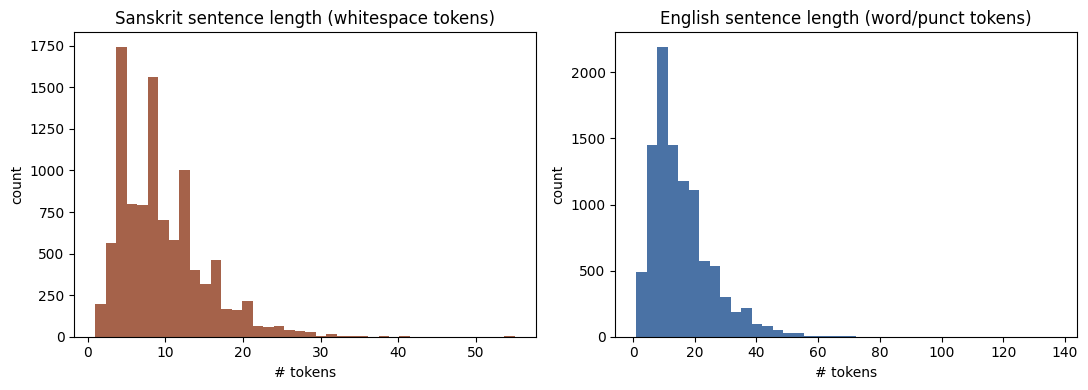

Sanskrit  -> mean 9.7, 95th pct 20
English   -> mean 15.6, 95th pct 35


In [29]:
def rough_len_sa(s):
    return len(s.split())

def rough_len_en(s):
    return len(re.findall(r"[A-Za-z']+|[^\sA-Za-z']", s))

train_df['sa_len'] = train_df['sa'].apply(rough_len_sa)
train_df['en_len'] = train_df['en'].apply(rough_len_en)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(train_df['sa_len'], bins=40, color='#a5624a')
ax[0].set_title('Sanskrit sentence length (whitespace tokens)')
ax[1].hist(train_df['en_len'], bins=40, color='#4a72a5')
ax[1].set_title('English sentence length (word/punct tokens)')
for a in ax:
    a.set_xlabel('# tokens'); a.set_ylabel('count')
plt.tight_layout(); plt.show()

print('Sanskrit  -> mean %.1f, 95th pct %d' % (train_df['sa_len'].mean(), np.percentile(train_df['sa_len'], 95)))
print('English   -> mean %.1f, 95th pct %d' % (train_df['en_len'].mean(), np.percentile(train_df['en_len'], 95)))

## 3. Preprocessing & Tokenization


In [30]:
punct_re = re.compile(r'([.,!?;:()[\u0964\u0965])')
space_re = re.compile(r'\s+')

def clean(text, lower=False):
    text = str(text).strip()
    if lower:
        text = text.lower()
    text = punct_re.sub(r' \1 ', text)
    text = space_re.sub(' ', text).strip()
    return text

def tokenize(text, lower=False):
    return clean(text, lower=lower).split(' ')

PAD, SOS, EOS, UNK = '<pad>', '<sos>', '<eos>', '<unk>'

class Vocab:
    def __init__(self, sentences, min_freq=2):
        cnt = Counter()
        for s in sentences:
            cnt.update(s)
        self.itos = [PAD, SOS, EOS, UNK]
        for tok, freq in cnt.most_common():
            if freq >= min_freq:
                self.itos.append(tok)
        self.stoi = {t: i for i, t in enumerate(self.itos)}

    def __len__(self):
        return len(self.itos)

    def encode(self, toks, add_sos_eos=True):
        ids = [self.stoi.get(t, self.stoi[UNK]) for t in toks]
        return [self.stoi[SOS]] + ids + [self.stoi[EOS]] if add_sos_eos else ids

    def decode(self, ids):
        return [self.itos[i] for i in ids if self.itos[i] not in (PAD, SOS, EOS)]

HAS_TEST_REFS = True

train_df['sa_tok'] = train_df['sa'].apply(lambda s: tokenize(s))
train_df['en_tok'] = train_df['en'].apply(lambda s: tokenize(s, lower=True))
dev_df['sa_tok']   = dev_df['sa'].apply(lambda s: tokenize(s))
dev_df['en_tok']   = dev_df['en'].apply(lambda s: tokenize(s, lower=True))
test_df['sa_tok']  = test_df['sa'].apply(lambda s: tokenize(s))
if HAS_TEST_REFS:
    test_df['en_tok'] = test_df['en'].apply(lambda s: tokenize(s, lower=True))

src_vocab = Vocab(train_df['sa_tok'], min_freq=2)
tgt_vocab = Vocab(train_df['en_tok'], min_freq=2)
print('sa vocab:', len(src_vocab), '| en vocab:', len(tgt_vocab))

sa vocab: 8419 | en vocab: 5731


In [31]:
train_df[['sa', 'sa_tok']].head(3)


,sa,sa_tok
0,"""Ctrl, S नुत्वा रक्षन्तु।""","[""Ctrl, ,, S, नुत्वा, रक्षन्तु, ।, ""]"
1,गुरुः छात्रान् एकवारं पाठयति ।,"[गुरुः, छात्रान्, एकवारं, पाठयति, ।]"
2,चित्रचालनमिदं पुनः कर्तुं मया अस्याः राशेः चित...,"[चित्रचालनमिदं, पुनः, कर्तुं, मया, अस्याः, राश..."


In [32]:
Max_lenth = 80

class TranslationDataset(Dataset):
    def __init__(self, df, has_target=True):
        self.src = [src_vocab.encode(t)[:Max_lenth] for t in df['sa_tok']]
        self.has_target = has_target
        self.tgt = [tgt_vocab.encode(t)[:Max_lenth] for t in df['en_tok']] if has_target else None
        self.ids = df['Source_id'].tolist()

    def __len__(self):
        return len(self.src)

    def __getitem__(self, i):
        if self.has_target:
            return self.src[i], self.tgt[i], self.ids[i]
        return self.src[i], self.ids[i]


def collate(batch):
    srcs, tgts, ids = zip(*batch)
    slens = [len(s) for s in srcs]
    tlens = [len(t) for t in tgts]
    src_pad = torch.full((len(batch), max(slens)), src_vocab.stoi[PAD], dtype=torch.long)
    tgt_pad = torch.full((len(batch), max(tlens)), tgt_vocab.stoi[PAD], dtype=torch.long)
    for i, (s, t) in enumerate(zip(srcs, tgts)):
        src_pad[i, :len(s)] = torch.tensor(s)
        tgt_pad[i, :len(t)] = torch.tensor(t)
    return src_pad, torch.tensor(slens), tgt_pad, torch.tensor(tlens), list(ids)


def collate_infer(batch):
    srcs, ids = zip(*batch)
    slens = [len(s) for s in srcs]
    src_pad = torch.full((len(batch), max(slens)), src_vocab.stoi[PAD], dtype=torch.long)
    for i, s in enumerate(srcs):
        src_pad[i, :len(s)] = torch.tensor(s)
    return src_pad, torch.tensor(slens), list(ids)


BATCH_SIZE = 64
train_ds = TranslationDataset(train_df)
dev_ds = TranslationDataset(dev_df)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate)
dev_loader = DataLoader(dev_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)

print('train batches:', len(train_loader))

train batches: 157


## 5. Model




In [33]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim, dropout=0.3):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=src_vocab.stoi[PAD])
        self.rnn = nn.GRU(emb_dim, hid_dim, bidirectional=True, batch_first=True)
        self.fc = nn.Linear(hid_dim * 2, hid_dim)
        self.drop = nn.Dropout(dropout)

    def forward(self, src, src_lens):
        embedded = self.drop(self.emb(src))
        packed = nn.utils.rnn.pack_padded_sequence(embedded, src_lens.cpu(), batch_first=True, enforce_sorted=False)
        out, hidden = self.rnn(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True)
        hidden = torch.tanh(self.fc(torch.cat((hidden[0], hidden[1]), dim=1)))
        return out, hidden


class Attention(nn.Module):
    def __init__(self, hid_dim):
        super().__init__()
        self.attn = nn.Linear(hid_dim * 3, hid_dim)
        self.v = nn.Linear(hid_dim, 1, bias=False)

    def forward(self, dec_hidden, enc_out, mask):
        src_len = enc_out.size(1)
        rep = dec_hidden.unsqueeze(1).repeat(1, src_len, 1)
        energy = torch.tanh(self.attn(torch.cat((rep, enc_out), dim=2)))
        scores = self.v(energy).squeeze(2)
        scores = scores.masked_fill(mask == 0, -1e10)
        return F.softmax(scores, dim=1)


class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim, dropout=0.3):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=tgt_vocab.stoi[PAD])
        self.attention = Attention(hid_dim)
        self.rnn = nn.GRU(emb_dim + hid_dim * 2, hid_dim, batch_first=True)
        self.fc_out = nn.Linear(hid_dim * 3 + emb_dim, vocab_size)
        self.drop = nn.Dropout(dropout)

    def forward(self, tok, hidden, enc_out, mask):
        embedded = self.drop(self.emb(tok)).unsqueeze(1)
        attw = self.attention(hidden, enc_out, mask)
        ctx = torch.bmm(attw.unsqueeze(1), enc_out)
        rnn_in = torch.cat((embedded, ctx), dim=2)
        out, hidden = self.rnn(rnn_in, hidden.unsqueeze(0))
        out, ctx, embedded = out.squeeze(1), ctx.squeeze(1), embedded.squeeze(1)
        pred = self.fc_out(torch.cat((out, ctx, embedded), dim=1))
        return pred, hidden.squeeze(0), attw


class Seq2Seq(nn.Module):
    def __init__(self, enc, dec, src_pad_idx):
        super().__init__()
        self.enc = enc
        self.dec = dec
        self.src_pad_idx = src_pad_idx

    def make_mask(self, src):
        return (src != self.src_pad_idx).to(src.device)

    def forward(self, src, src_lens, tgt, tf_ratio=0.5):
        batch, tgt_len = tgt.shape
        vocab_size = self.dec.fc_out.out_features
        outputs = torch.zeros(batch, tgt_len, vocab_size, device=src.device)

        enc_out, hidden = self.enc(src, src_lens)
        mask = self.make_mask(src)
        tok = tgt[:, 0]
        for t in range(1, tgt_len):
            pred, hidden, _ = self.dec(tok, hidden, enc_out, mask)
            outputs[:, t] = pred
            tok = tgt[:, t] if random.random() < tf_ratio else pred.argmax(1)
        return outputs


### Hyperparams + training loop

In [34]:
EMB_DIM = 256
HID_DIM = 512
DROPOUT = 0.3
EPOCHS = 20
CLIP = 1.0
LR = 1e-3
PATIENCE = 3

enc = Encoder(len(src_vocab), EMB_DIM, HID_DIM, DROPOUT)
dec = Decoder(len(tgt_vocab), EMB_DIM, HID_DIM, DROPOUT)
model = Seq2Seq(enc, dec, src_vocab.stoi[PAD]).to(device)

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print(f'{count_params(model):,} trainable params available')

opt = torch.optim.Adam(model.parameters(), lr=LR)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=1)
loss_fn = nn.CrossEntropyLoss(ignore_index=tgt_vocab.stoi[PAD], label_smoothing=0.1)


20,331,363 trainable params available


In [35]:
def run_epoch(loader, train=True, tf_ratio=0.5):
    model.train() if train else model.eval()
    total_loss = 0
    with torch.set_grad_enabled(train):
        for src, src_lens, tgt, tgt_lens, _ in loader:
            src, tgt = src.to(device), tgt.to(device)
            if train:
                opt.zero_grad()
            out = model(src, src_lens, tgt, tf_ratio=tf_ratio if train else 0.0)
            loss = loss_fn(out[:, 1:].reshape(-1, out.shape[-1]), tgt[:, 1:].reshape(-1))
            if train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), CLIP)
                opt.step()
            total_loss += loss.item()
    return total_loss / len(loader)


In [36]:
train_losses, dev_losses = [], []
best_dev_loss = float('inf')
bad_epochs = 0

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_loss = run_epoch(train_loader, train=True)
    dv_loss = run_epoch(dev_loader, train=False)
    sched.step(dv_loss)

    train_losses.append(tr_loss)
    dev_losses.append(dv_loss)
    print(f'epoch {epoch:02d}/{EPOCHS}  train {tr_loss:.4f}  dev {dv_loss:.4f}  ppl {math.exp(dv_loss):.1f}  ({time.time()-t0:.0f}s)')

    if dv_loss < best_dev_loss:
        best_dev_loss = dv_loss
        bad_epochs = 0
        torch.save(model.state_dict(), 'best_model.pt')
    else:
        bad_epochs += 1

model.load_state_dict(torch.load('best_model.pt'))


epoch 01/20  train 6.0026  dev 5.7996  ppl 330.2  (66s)
epoch 02/20  train 5.3338  dev 5.5749  ppl 263.7  (57s)
epoch 03/20  train 4.8345  dev 5.5789  ppl 264.8  (60s)
epoch 04/20  train 4.3578  dev 5.6109  ppl 273.4  (57s)
epoch 05/20  train 3.8729  dev 5.5910  ppl 268.0  (58s)
epoch 06/20  train 3.6338  dev 5.6130  ppl 274.0  (58s)
epoch 07/20  train 3.4426  dev 5.6145  ppl 274.4  (58s)
epoch 08/20  train 3.3220  dev 5.6371  ppl 280.6  (57s)
epoch 09/20  train 3.2229  dev 5.6516  ppl 284.8  (58s)
epoch 10/20  train 3.1737  dev 5.6587  ppl 286.8  (58s)
epoch 11/20  train 3.1051  dev 5.6699  ppl 290.0  (58s)
epoch 12/20  train 3.0943  dev 5.6777  ppl 292.3  (58s)
epoch 13/20  train 3.0616  dev 5.6798  ppl 292.9  (58s)
epoch 14/20  train 3.0422  dev 5.6895  ppl 295.7  (57s)
epoch 15/20  train 3.0322  dev 5.6924  ppl 296.6  (58s)
epoch 16/20  train 3.0307  dev 5.7019  ppl 299.4  (57s)
epoch 17/20  train 3.0103  dev 5.7004  ppl 299.0  (58s)
epoch 18/20  train 3.0131  dev 5.7005  ppl 299.0

<All keys matched successfully>

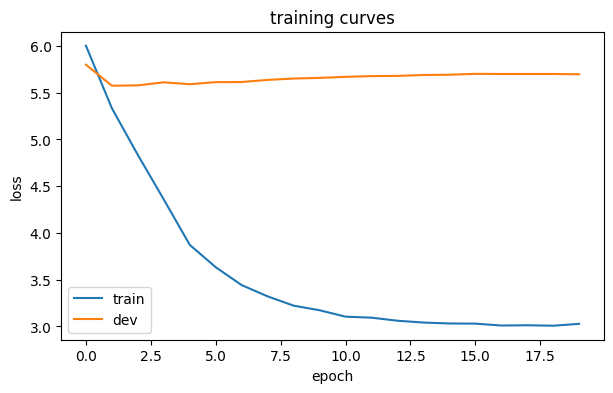

In [37]:
plt.figure(figsize=(7, 4))
plt.plot(train_losses, label='train')
plt.plot(dev_losses, label='dev')
plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend(); plt.title('training curves')
plt.savefig('training_curves.png', dpi=150)
plt.show()


## 7. Decoding: Greedy & Beam Search


In [38]:
import torch.nn.functional as F

MAX_LEN_SRC = Max_lenth

@torch.no_grad()
def greedy_translate(model, sentence, sa_vocab, en_vocab, max_len=60):
    model.eval()
    ids = sa_vocab.encode(tokenize(sentence))[:MAX_LEN_SRC]
    src = torch.tensor(ids, dtype=torch.long, device=device).unsqueeze(0)
    src_lens = torch.tensor([len(ids)])
    enc_out, hidden = model.enc(src, src_lens)
    src_mask = model.make_mask(src)

    input_tok = torch.tensor([en_vocab.stoi[SOS]], device=device)
    out_ids = []
    for _ in range(max_len):
        logits, hidden, _ = model.dec(input_tok, hidden, enc_out, src_mask)
        next_id = logits.argmax(-1)
        if next_id.item() == en_vocab.stoi[EOS]:
            break
        out_ids.append(next_id.item())
        input_tok = next_id
    return ' '.join(en_vocab.decode(out_ids))


@torch.no_grad()
def beam_search_translate(model, sentence, sa_vocab, en_vocab, beam_width=5, max_len=60, len_penalty=0.7):
    model.eval()
    ids = sa_vocab.encode(tokenize(sentence))[:MAX_LEN_SRC]
    src = torch.tensor(ids, dtype=torch.long, device=device).unsqueeze(0)
    src_lens = torch.tensor([len(ids)])
    enc_out, hidden = model.enc(src, src_lens)
    src_mask = model.make_mask(src)
    hid_dim = HID_DIM

    beams = [([en_vocab.stoi[SOS]], 0.0, hidden, False)]

    for _ in range(max_len):
        all_candidates = []
        for tokens, score, h, finished in beams:
            if finished:
                all_candidates.append((tokens, score, h, True))
                continue
            input_tok = torch.tensor([tokens[-1]], device=device)
            logits, h2, _ = model.dec(input_tok, h, enc_out, src_mask)
            log_probs = F.log_softmax(logits, dim=-1).squeeze(0)
            topk_lp, topk_idx = log_probs.topk(beam_width)
            for lp, idx in zip(topk_lp.tolist(), topk_idx.tolist()):
                fin = (idx == en_vocab.stoi[EOS])
                all_candidates.append((tokens + [idx], score + lp, h2, fin))

        def norm_score(cand):
            toks, sc = cand[0], cand[1]
            length = max(len(toks) - 1, 1)
            return sc / (length ** len_penalty)

        all_candidates.sort(key=norm_score, reverse=True)
        beams = all_candidates[:beam_width]
        if all(b[-1] for b in beams):
            break

    best = max(beams, key=norm_score)
    out_ids = [t for t in best[0][1:] if t != en_vocab.stoi[EOS]] # Correct EOS check here too
    return ' '.join(en_vocab.decode(out_ids))

print(greedy_translate(model, dev_df['sa'].iloc[0], src_vocab, tgt_vocab))
print(beam_search_translate(model, dev_df['sa'].iloc[0], src_vocab, tgt_vocab, beam_width=5))
print('Reference:', dev_df['en'].iloc[0])

those two are two .
those are two .
Reference: Those are brave men.


## 8. Evaluation Metrics: BLEU, BERTScore, efficiency


In [52]:
def predict(model, df, src_vocab, tgt_vocab, beam_width=5):
    preds = []
    for sentence in df['sa']:
        translated_sentence = beam_search_translate(model, sentence, src_vocab, tgt_vocab, beam_width=beam_width)
        preds.append(translated_sentence)
    return preds

dev_preds = predict(model, dev_df, src_vocab, tgt_vocab, beam_width=5)
refs = [[toks] for toks in dev_df['en_tok']]
hyps = [p.split(' ') for p in dev_preds]

bleu = corpus_bleu(refs, hyps)
print('dev BLEU:', round(bleu * 100, 2))

dev BLEU: 4.99


In [46]:
from bert_score import score as bertscore

dev_preds = predict(model, dev_df, src_vocab, tgt_vocab, beam_width=5)

P, R, F1 = bertscore(dev_preds, dev_df['en'].tolist(), lang='en', rescale_with_baseline=True, verbose=True)
print('dev BERTScore F1:', round(F1.mean().item(), 4))

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


calculating scores...
computing bert embedding.


  0%|          | 0/29 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/16 [00:00<?, ?it/s]

done in 9.44 seconds, 105.91 sentences/sec
dev BERTScore F1: -0.0364


In [45]:
n_params = count_params(model)
t0 = time.time()
test_preds = predict(model, test_df, src_vocab, tgt_vocab, beam_width=5)
infer_time = time.time() - t0

print('Efficiency summary')
print(f'Total trainable parameters {n_params:,}')
print(f'inference time on {len(test_df)} test sentences: {infer_time:.1f}s  ({infer_time/len(test_df)*1000:.1f} ms/sentence)')
print(f'Device used for inference  : {device}')

print(f'BLEU              : {round(bleu * 100, 2)}')
print(f'BERTScore F1       : {round(F1.mean().item(), 4):.4f}')

Efficiency summary
Total trainable parameters 20,331,363
inference time on 1000 test sentences: 89.9s  (89.9 ms/sentence)
Device used for inference  : cuda
BLEU              : 4.99
BERTScore F1       : -0.0364


## 9. Create submission.csv

In [42]:
submission = pd.DataFrame({'Source_id': test_df['Source_id'], 'Sentence_en': test_preds})
submission.to_csv('submission.csv', index=False, encoding='utf-8')
submission.head(10)
try:
    from google.colab import files
    files.download('submission.csv')
except ImportError:
    print('Saved submission.csv to the current working directory.')



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [43]:
if HAS_TEST_REFS:
    refs_t = [[toks] for toks in test_df['en_tok']]
    hyps_t = [p.split(' ') for p in test_preds]
    print('test BLEU:', round(corpus_bleu(refs_t, hyps_t) * 100, 2))
    _, _, f1_t = bertscore(test_preds, test_df['en'].tolist(), lang='en', rescale_with_baseline=True)
    print('test BERTScore F1:', round(f1_t.mean().item(), 4))


test BLEU: 4.61


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


test BERTScore F1: -0.0404


## 10. Qualitative Translation Examples & Error Analysis

In [44]:
for i in random.sample(range(len(dev_df)), 8):
    print('SRC :', dev_df.iloc[i]['sa'])
    print('REF :', dev_df.iloc[i]['en'])
    print('PRED:', dev_preds[i])
    print()


SRC : अतएवेश्वरस्य राज्यार्थं सचेष्टा भवत तथा कृते सर्व्वाण्येतानि द्रव्याणि युष्मभ्यं प्रदायिष्यन्ते।
REF : But rather seek ye the kingdom of God; and all these things shall be added unto you.
PRED: "and the and of the and and the and of god , and the and of the . "

SRC : 6. श्वसनतन्त्रस्य केषाञ्चन चतुर्णां भागानां नाम लिखन्तु।
REF : 6. write only four parts of respiratory system?
PRED: 6 .

SRC : Spectra Visualization (स्पेक्ट्रा विज़ुवलैसेशन्) विण्डो उद्घट्यते । इदं बेंज़ीन् इत्यस्य गणितं  IR spectrum इतीदं दर्शयति ।
REF : A Spectra Visualization window opens. It shows the calculated IR spectrum of Benzene.
PRED: click on the dialog box appears .

SRC : Patrons and circulation अधः, Patron categories उपरि क्लिक् कुर्वन्तु ।
REF : Under Patrons and circulation, click on Patron categories.
PRED: click on the and click on the tab .

SRC : इदमहं निष्कासयामि। अत्र प्रत्यागत्य इदं संरक्षामि। पश्चात् सङ्कलयामि – pdflatex beamer ।
REF : Let me cut it, come back here, let me save it and then